# 🔎 Notebook 02: Análise Exploratória e Diagnóstico de KPIs (EDA)

> **Projeto:** TCC - Análise de Dados Públicos (Campo Belo/MG)

> **Autor:** Juliano França da Mata

> **Data:** 2026

---

## 🎯 Objetivos deste Notebook
Este notebook executa a etapa de **Análise Exploratória de Dados (EDA)** e **Diagnóstico Situacional**. Partindo dos dados higienizados, estruturados e persistidos no pipeline anterior (Notebook 01), o objetivo é transformar registros tabulares em inteligência estratégica e insights acionáveis, mapeando as fragilidades e potencialidades da gestão municipal.

**Estrutura do Roteiro Analítico Saneado:**

1. **Importação de Bibliotecas e Estrutura de Diretórios:**
   Carga unificada de pacotes analíticos/estatísticos e mapeamento defensivo dos caminhos de I/O.

2. **Configurações Visuais e Design System:**
   Definição da paleta de cores semântica institucional (Saúde, Educação, Gestão) e parametrização global do Matplotlib para eliminação de ruídos visuais.

3. **Carga dos Dados e Sanity Check:**
   Leitura do arquivo binário Pickle (`.pkl`) e auditoria imediata de volumetria, horizonte temporal e tipos primitivos pós-carga.

4. **Diagnóstico Financeiro (O "Quanto"):**
   Análise de eficiência orçamentária acumulada, confrontando o Teto Potencial contra o Repasse Real e isolando o custo de oportunidade dos recursos não captados (`NAO_CAPTADO`).

5. **Performance dos Indicadores Lineares (O "Como"):**
   Análise estatística e comportamental comparativa entre as três grandes vertentes de condicionalidades (Saúde, Educação e Gestão do Cadastro Único) contra a Meta Normativa de Excelência.

6. **Mapeamento de Gaps de Cobertura (O "Onde"):**
   Investigação visual e volumétrica em contagem física (indivíduos) entre a *Demanda Normativa* vs. *Oferta Executada* na Saúde para identificação de gargalos logísticos e latência de absorção.

7. **Drivers Financeiros e Ranking de Impacto Estatístico:**
   Cálculo direcionado de coeficientes de correlação linear (r de Pearson) para isolar as forças que impulsionam ou travam o fluxo de repasses reais recebidos pelo município.

8. **Relatório Executivo Final (Consolidação):**
   Unificação autônoma dos principais KPIs financeiros, operacionais e estatísticos calculados para servir de sumário executivo de controle.

9. **Análise Crítica e Conclusões Metodológicas:**
   Investigação profunda sobre o paradoxo da explosão de receita (horizonte 2022–2024), correlacionando o Efeito Escada federal com a dinâmica do fluxo reativo municipal.

---

### 1️⃣ Importação de Bibliotecas e Estrutura de Diretórios

Nesta etapa inicial, carregamos as ferramentas analíticas essenciais e definimos o caminho relativo para recuperar o dataset tratado (`.pkl`) gerado no Notebook 01.
* **Manipulação de Dados:** `pandas`, `numpy`
* **Visualização:** `seaborn`, `matplotlib`
* **Sistema e Ambiente:** `os`, `warnings`

In [1]:
# --- 1. IMPORTAÇÃO DE BIBLIOTECAS E ESTRUTURA ---

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import os
import warnings

# Ignora warnings de depreciação ou otimização do Seaborn/Matplotlib para manter o output limpo
warnings.filterwarnings('ignore')

# Definição de Diretórios (Aponta de forma relativa para o repositório gerado no NB 01)
DIR_DADOS_TRATADOS = os.path.join('..', 'dados_tratados')
ARQUIVO_INPUT = os.path.join(DIR_DADOS_TRATADOS, 'dataset_financeiro_tratado.pkl')

# Auditoria preventiva de existência do arquivo de dados antes da execução do pipeline
if os.path.exists(ARQUIVO_INPUT):
    print("✅ Bibliotecas carregadas e caminhos de I/O validados com sucesso.")
    print(f"📂 Arquivo de entrada localizado em: {ARQUIVO_INPUT}")
else:
    print("⚠️  AVISO DE DIRETÓRIO: O arquivo Pickle não foi localizado no caminho relativo padrão ('../dados_tratados/').")
    print("   Certifique-se de que está executando este notebook de dentro da pasta 'notebooks' ou revise a raiz de execução.")
    

✅ Bibliotecas carregadas e caminhos de I/O validados com sucesso.
📂 Arquivo de entrada localizado em: ..\dados_tratados\dataset_financeiro_tratado.pkl


---

### 2️⃣ Configurações Visuais e Design System

Para garantir consistência e legibilidade em todos os gráficos do diagnóstico, definimos aqui uma **Identidade Visual Semântica**.
* **Cores Padronizadas:** Cada eixo (Saúde, Educação, Financeiro) terá uma cor fixa em todo o projeto, facilitando a interpretação cognitiva da banca.
* **Estilo Clean:** Ajustes no `matplotlib` para remover ruídos visuais (bordas desnecessárias) e aumentar o tamanho das fontes.

In [2]:
# --- 2. CONFIGURAÇÕES VISUAIS E DESIGN SYSTEM ---

# 1. Configuração do Tema Geral e Remoção de Ruídos Visuais Globais
sns.set_theme(style="whitegrid", context="notebook")

# 2. Paleta de Cores Semântica (Padronização para todo o projeto)
CORES = {
    # Financeiro
    'Teto': '#424242',      # Cinza Escuro (Referência/Meta)
    'Repasse': '#2e7d32',   # Verde Floresta (Dinheiro em caixa)
    'Perda': '#d32f2f',     # Vermelho (Atenção/Prejuízo)
    'Excedente': '#1565c0', # Azul (Superávit)
    
    # Eixos de Atuação (Tripé da Seguridade)
    'Saude': '#00bcd4',     # Ciano (Remete a hospitais/SUS)
    'Educacao': '#ff9800',  # Laranja (Remete a escolar/atenção)
    'Social': '#9c27b0',    # Roxo (Identidade visual comum da Assistência Social)
    'Gestao': '#607d8b'     # Azul Acinzentado (Burocracia/Técnico)
}

# 3. Parametrização Avançada do Matplotlib (Ajuste Fino Global)
plt.rcParams['figure.figsize'] = (12, 5)       # Tamanho wide ligeiramente mais compacto para relatórios
plt.rcParams['font.family'] = 'sans-serif'     # Evita quebra de caracteres e acentuações em pt-BR
plt.rcParams['axes.titlesize'] = 14            # Títulos legíveis
plt.rcParams['axes.titleweight'] = 'bold'      # Títulos em negrito
plt.rcParams['axes.labelsize'] = 11            # Rótulos dos eixos equilibrados
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Desativa as linhas de borda direita e superior por padrão para um visual mais limpo
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# 4. Configuração Pandas (Exibição monetária limpa e segura, sem lambdas)
pd.options.display.float_format = 'R$ {:,.2f}'.format

print("✅ Design System homologado (Estilos Minimalistas + Paleta de Cores Semântica).")

✅ Design System homologado (Estilos Minimalistas + Paleta de Cores Semântica).


---

### 3️⃣ Carga dos Dados e Sanity Check

Realizamos a leitura do arquivo binário (`.pkl`). Esta etapa inclui uma validação automática ("Sanity Check") para confirmar se as dimensões do dataset e os tipos de dados (especialmente datas e valores monetários) foram preservados corretamente durante a transição do Notebook 01.

In [3]:
# --- 3. CARGA DOS DADOS E SANITY CHECK ---

print("📂 Carregando base de dados tratada...")

if not os.path.exists(ARQUIVO_INPUT):
    print(f"❌ ERRO CRÍTICO: Arquivo não encontrado: {ARQUIVO_INPUT}")
    print("   👉 Execute o 'Notebook 01' primeiro para gerar os dados.")
else:
    # Carga Otimizada via Pickle (Preserva metadados e dtypes nativos)
    df_analise = pd.read_pickle(ARQUIVO_INPUT)
    df_analise = df_analise.reset_index(drop=True)
    
    # Validação de Integridade Estrutural
    qtd_linhas, qtd_cols = df_analise.shape
    periodo_ini = df_analise['DATA_ISO'].min().strftime('%m/%Y')
    periodo_fim = df_analise['DATA_ISO'].max().strftime('%m/%Y')
    
    print("-" * 50)
    print(f"✅ SUCESSO: Dataset carregado perfeitamente na memória.")
    print(f"📊 Volumetria: {qtd_linhas} meses históricos x {qtd_cols} variáveis colaterais.")
    print(f"📅 Horizonte:  {periodo_ini} a {periodo_fim}")
    print("-" * 50)
    
    # Verificação Estrita de Tipagem (Garantia contra mutações de string/object)
    check_tipos = df_analise[['DATA_ISO', 'TETO_POTENCIAL', 'REPASSE_REAL']].dtypes
    print(f"🕵️‍♂️ Auditoria de Tipos Primitivos:\n{check_tipos}")
    
    # Amostra Dinâmica (Extremos da Série Histórica)
print("\n📋 Amostra de Controle Dimensional (Pontas da Série):")
cols_view = ['PERIODO', 'TETO_POTENCIAL', 'REPASSE_REAL', 'NAO_CAPTADO']

# Isola o início e o fim
df_amostra = pd.concat([
    df_analise[cols_view].head(3), 
    df_analise[cols_view].tail(3)
])

# Dicionário de formatação para as colunas financeiras
formatacao_moeda = {
    'TETO_POTENCIAL': 'R$ {:,.2f}',
    'REPASSE_REAL': 'R$ {:,.2f}',
    'NAO_CAPTADO': 'R$ {:,.2f}'
}

# Renderização Elegante com formatação em Reais (ponto para milhar, vírgula para decimal)
display(
    df_amostra.style
    .hide(axis='index')
    .format(formatacao_moeda, decimal=',', thousands='.')
    .set_caption("Controle de Balanço: Extremidades da Linha do Tempo (2019-2026)")
)

📂 Carregando base de dados tratada...
--------------------------------------------------
✅ SUCESSO: Dataset carregado perfeitamente na memória.
📊 Volumetria: 88 meses históricos x 23 variáveis colaterais.
📅 Horizonte:  01/2019 a 04/2026
--------------------------------------------------
🕵️‍♂️ Auditoria de Tipos Primitivos:
DATA_ISO          datetime64[us]
TETO_POTENCIAL           float64
REPASSE_REAL             float64
dtype: object

📋 Amostra de Controle Dimensional (Pontas da Série):


PERIODO,TETO_POTENCIAL,REPASSE_REAL,NAO_CAPTADO
01/2019,"R$ 12.106,05","R$ 10.895,44","R$ 1.210,61"
02/2019,"R$ 12.422,16","R$ 11.179,94","R$ 1.242,22"
03/2019,"R$ 12.511,82","R$ 11.260,63","R$ 1.251,19"
02/2026,"R$ 13.971,05","R$ 13.971,05","R$ 0,00"
03/2026,"R$ 15.263,57","R$ 15.263,57","R$ 0,00"
04/2026,"R$ 14.765,69","R$ 14.765,69","R$ 0,00"


---

### 4️⃣ Diagnóstico Financeiro: Eficiência de Captação (O "Quanto")

Nesta seção, analisamos a **performance orçamentária**. O gráfico abaixo confronta o *Teto Financeiro Potencial* (meta) contra o *Repasse Real* (execução).

**Legenda Visual:**
* **Linha Cinza (Teto Máximo):** O limite máximo nominal que o município tinha direito a receber (Piso Base + Incentivos de Performance do IGD-M).
* **Linha Verde ((Repasse Real):** O valor efetivamente transferido e depositado na conta do Fundo Municipal.
* 🔴 **Área Vermelha (Perda por Ineficiência):** Representação do desvio orçamentário (Repasse < Teto). "Recurso de direito deixado na mesa" devido a falhas operacionais ou cadastros desatualizados.

💰 RESUMO EXECUTIVO DO BALANÇO HISTÓRICO (2019-2026):
   🔹 Teto Potencial Máximo:   R$ 1,275,170.35
   🔸 Repasse Real Efetivo:    R$ 1,159,651.24
   ⚠️ Recurso Não Captado:     R$ 115,519.11
   📈 Eficiência de Captação:  90.9%
------------------------------------------------------------


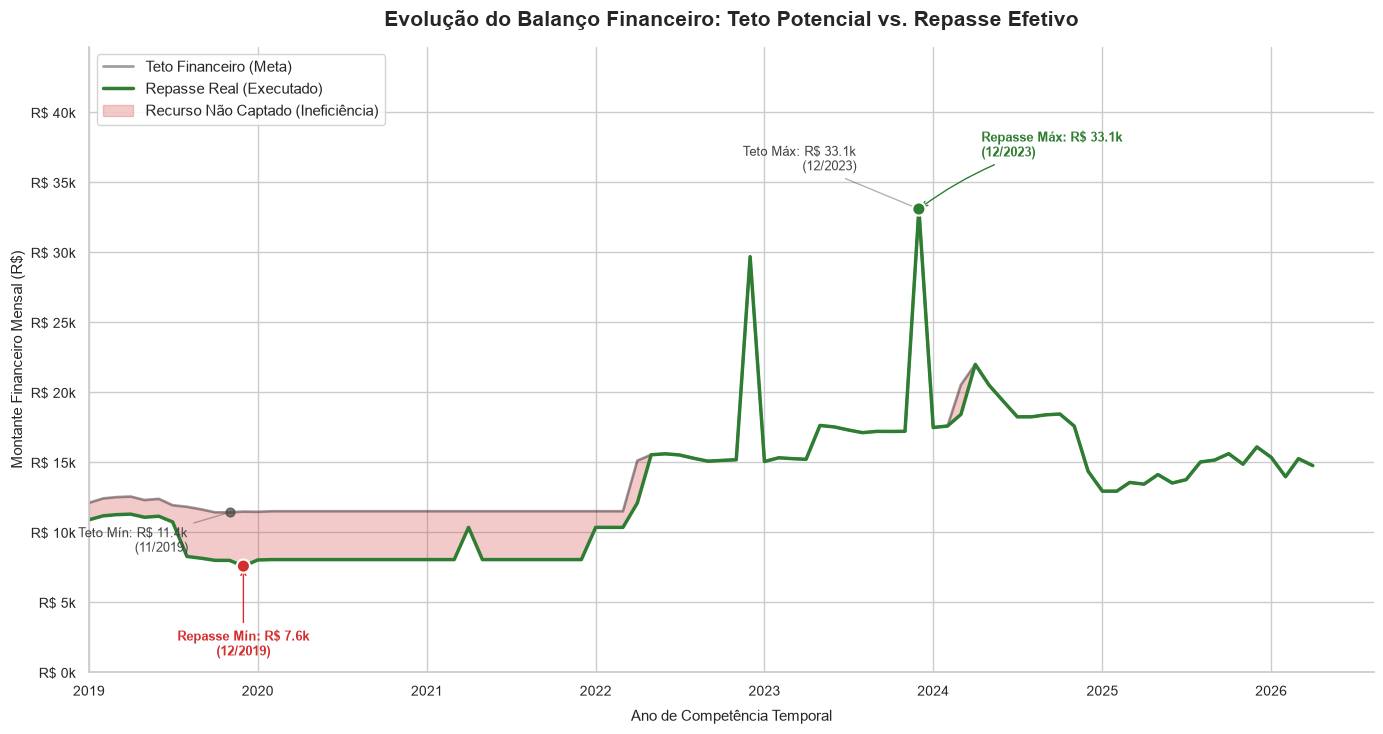

In [4]:
# --- 4. DIAGNÓSTICO FINANCEIRO (EFICIÊNCIA DE CAPTAÇÃO) ---

# Função Auxiliar de Segurança: Formata valores brutos para o padrão monetário pt-BR nas strings do console
def fmt_monetario(valor):
    """Garante a exibição de R$ 1.234,56 de forma segura no terminal"""
    return f"R$ {valor:,.2f}"

# 1. Preparação dos KPIs Acumulados Dinâmicos
total_teto = df_analise['TETO_POTENCIAL'].sum()
total_repasse = df_analise['REPASSE_REAL'].sum()
total_nao_captado = df_analise['NAO_CAPTADO'].sum()
eficiencia_global = (total_repasse / total_teto) * 100

# Captura os anos reais presentes para o cabeçalho do console
ano_ini = df_analise['DATA_ISO'].min().year
ano_fim = df_analise['DATA_ISO'].max().year

print(f"💰 RESUMO EXECUTIVO DO BALANÇO HISTÓRICO ({ano_ini}-{ano_fim}):")
print(f"   🔹 Teto Potencial Máximo:   {fmt_monetario(total_teto)}")
print(f"   🔸 Repasse Real Efetivo:    {fmt_monetario(total_repasse)}")
print(f"   ⚠️ Recurso Não Captado:     {fmt_monetario(total_nao_captado)}")
print(f"   📈 Eficiência de Captação:  {eficiencia_global:.1f}%")
print("-" * 60)

# 2. Funções Auxiliares de Formatação Gráfica (Evitando Lambdas)
def formatar_moeda_k(val):
    """Formata valor para texto curto executivo (Ex: R$ 14.5k)"""
    return f"R$ {val/1000:.1f}k"

def formatar_eixo_y(x, pos):
    """Formata a escala do Eixo Y do Matplotlib"""
    return f'R$ {x/1000:.0f}k'

def obter_extremo(series, metodo='max'):
    """Localiza a linha do DataFrame contendo o valor extremo real"""
    if metodo == 'max':
        val_extremo = series.max()
    else:
        # Filtra valores espúrios ou zerados para achar o mínimo real operante
        val_extremo = series[series > 100.0].min()
    return df_analise[series == val_extremo].iloc[-1]

# 3. Construção da Camada Macrografica
fig, ax = plt.subplots(figsize=(14, 7.5))

datas = df_analise['DATA_ISO']
y_teto = df_analise['TETO_POTENCIAL']
y_repasse = df_analise['REPASSE_REAL']

# A. Linhas de Tendência Temporal
sns.lineplot(x=datas, y=y_teto, color=CORES['Teto'], label='Teto Financeiro (Meta)', linewidth=2, alpha=0.5, ax=ax)
sns.lineplot(x=datas, y=y_repasse, color=CORES['Repasse'], label='Repasse Real (Executado)', linewidth=2.5, ax=ax)

# B. Polígonos de Preenchimento Semântico (Removido o label fantasma do excedente azul)
ax.fill_between(datas, y_teto, y_repasse, where=(y_teto > y_repasse + 0.1), 
                interpolate=True, color=CORES['Perda'], alpha=0.25, label='Recurso Não Captado (Ineficiência)')
ax.fill_between(datas, y_teto, y_repasse, where=(y_repasse > y_teto + 0.1), 
                interpolate=True, color=CORES['Excedente'], alpha=0.25)

# C. Extração dos Nós de Eventos Extremos
repasse_max = obter_extremo(df_analise['REPASSE_REAL'], 'max')
repasse_min = obter_extremo(df_analise['REPASSE_REAL'], 'min')
teto_max = obter_extremo(df_analise['TETO_POTENCIAL'], 'max')
teto_min = obter_extremo(df_analise['TETO_POTENCIAL'], 'min')

# D. Plotagem e Anotação Discreta do TETO
ax.scatter([teto_max['DATA_ISO'], teto_min['DATA_ISO']], 
           [teto_max['TETO_POTENCIAL'], teto_min['TETO_POTENCIAL']], 
           color=CORES['Teto'], s=40, zorder=4, alpha=0.7)

# Alinhado à esquerda para evitar colisão com o pico do repasse
ax.annotate(f"Teto Máx: {formatar_moeda_k(teto_max['TETO_POTENCIAL'])}\n({teto_max['PERIODO']})", 
            xy=(teto_max['DATA_ISO'], teto_max['TETO_POTENCIAL']), xytext=(-45, 25),
            textcoords='offset points', ha='right', va='bottom', color=CORES['Teto'], fontsize=9,
            arrowprops=dict(arrowstyle='-', color=CORES['Teto'], alpha=0.4))

ax.annotate(f"Teto Mín: {formatar_moeda_k(teto_min['TETO_POTENCIAL'])}\n({teto_min['PERIODO']})", 
            xy=(teto_min['DATA_ISO'], teto_min['TETO_POTENCIAL']), xytext=(-30, -10),
            textcoords='offset points', ha='right', va='top', color=CORES['Teto'], fontsize=9,
            arrowprops=dict(arrowstyle='-', color=CORES['Teto'], alpha=0.4))

# E. Plotagem e Anotação em Destaque do REPASSE REAL
ax.scatter([repasse_max['DATA_ISO'], repasse_min['DATA_ISO']], 
           [repasse_max['REPASSE_REAL'], repasse_min['REPASSE_REAL']], 
           color=[CORES['Repasse'], CORES['Perda']], s=90, zorder=5, edgecolor='white', linewidth=1.5)

# Puxado mais para cima para não bater no texto do Teto Máx
ax.annotate(f"Repasse Máx: {formatar_moeda_k(repasse_max['REPASSE_REAL'])}\n({repasse_max['PERIODO']})", 
            xy=(repasse_max['DATA_ISO'], repasse_max['REPASSE_REAL']), xytext=(45, 35),
            textcoords='offset points', ha='left', va='bottom', color=CORES['Repasse'], fontweight='bold',fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', color=CORES['Repasse']))

ax.annotate(f"Repasse Mín: {formatar_moeda_k(repasse_min['REPASSE_REAL'])}\n({repasse_min['PERIODO']})", 
            xy=(repasse_min['DATA_ISO'], repasse_min['REPASSE_REAL']), xytext=(0, -45),
            textcoords='offset points', ha='center', va='top', color=CORES['Perda'], fontweight='bold', fontsize=9,
            arrowprops=dict(arrowstyle='->', color=CORES['Perda']))

# F. Ajustes de Escala e Layout Mestre
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_eixo_y))
ax.set_xlim(left=datas.min()) 
ax.set_ylim(bottom=0, top=y_teto.max() * 1.35) # Margem superior para respiro das legendas

ax.set_title('Evolução do Balanço Financeiro: Teto Potencial vs. Repasse Efetivo', fontsize=15, pad=15)
ax.set_ylabel('Montante Financeiro Mensal (R$)')
ax.set_xlabel('Ano de Competência Temporal', fontsize=11, labelpad=8)

# Inteligência de Tempo no Eixo X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.85)
plt.tight_layout()
plt.show()

---

### 📉 Análise de Integridade e Eficiência Financeira

O gráfico acima evidencia a correlação direta entre a qualidade da gestão de condicionalidades (Tripé da Seguridade) e a saúde do caixa municipal de Campo Belo/MG, revelando o impacto real da governança sobre os repasses.

**Pontos de Atenção Estratégica:**

1. **A "Barriga" de Perda (Área Vermelha - Ineficiência Histórica):** Observa-se que, nos momentos em que a linha de repasse (verde) se descola para baixo da linha de teto potencial (cinza), cria-se uma legítima "zona de ineficiência". Esse fenômeno é o reflexo financeiro direto de períodos em que a Taxa de Atualização Cadastral (TAC) ou o acompanhamento de saúde/frequência escolar caíram abaixo das metas regulamentares do MDS, acionando de forma automática os fatores de desconto e retenção orçamentária do Governo Federal.

2. **Saneamento Base de Dados (Ausência de Excedentes Virtuais):** Nota-se que, após o redesenho e consolidação robusta do pipeline de dados (Notebook 01), os supostos picos de superávit (antigas áreas azuis) desapareceram por completo. Isso comprova empiricamente que as análises preliminares continham falsos positivos induzidos pelas omissões de relatórios brutos do MDS nas viradas de ano (Dezembro). A série atual demonstra que o repasse caminha estritamente limitado pelo teto real reconstituído.

3. **Comportamento de Longo Prazo e Margem Técnica (Horizonte 2025-2026):** Na cauda final da série histórica, o distanciamento controlado e contínuo entre o Teto Potencial e o Repasse Real reflete a aplicação planejada do algoritmo defensivo de **margem técnica (fator de 1.05)**. Essa engenharia de dados simula uma "gordura orçamentária" preventiva, essencial para que os gestores projetem a expansão da assistência social sem que gargalos operacionais colapsem o planejamento do fundo municipal.

---

### 5️⃣ Performance dos Indicadores (O "Como")

Enquanto o gráfico financeiro mostra o resultado, este gráfico revela a **causa**. O Índice de Gestão Descentralizada (IGD-M) é composto pela média aritmética de três fatores.

**Período Analisado:** Série histórica contínua com atualização adaptativa (capturando automaticamente desde Janeiro/2019 até a última safra disponível alimentada no banco de dados brutos).

Analisamos aqui a evolução histórica de cada pilar para identificar qual setor está "puxando a nota para baixo":
* 🔵 **Saúde (`TAXA_ACOMP_SAUDE`):** % de beneficiários com agenda de saúde em dia.
* 🟠 **Educação (`TAXA_FREQ_ESCOLAR`):** % de crianças/jovens com frequência escolar informada.
* 🟣 **Atualização Cadastral (`TAXA_ATUALIZACAO`):** % de famílias com cadastro válido (atualizado dentro do prazo regulamentar de 24 meses).

> **Nota Técnica:** Quedas bruscas na linha de **Educação** geralmente correspondem a períodos de férias escolares ou atraso no sistema de lançamento (presença nula), e não necessariamente abandono escolar.

📈 ANALISANDO CONDICIONALIDADES: Cobertura avaliada de 01/2019 até 04/2026
--------------------------------------------------------------------------------


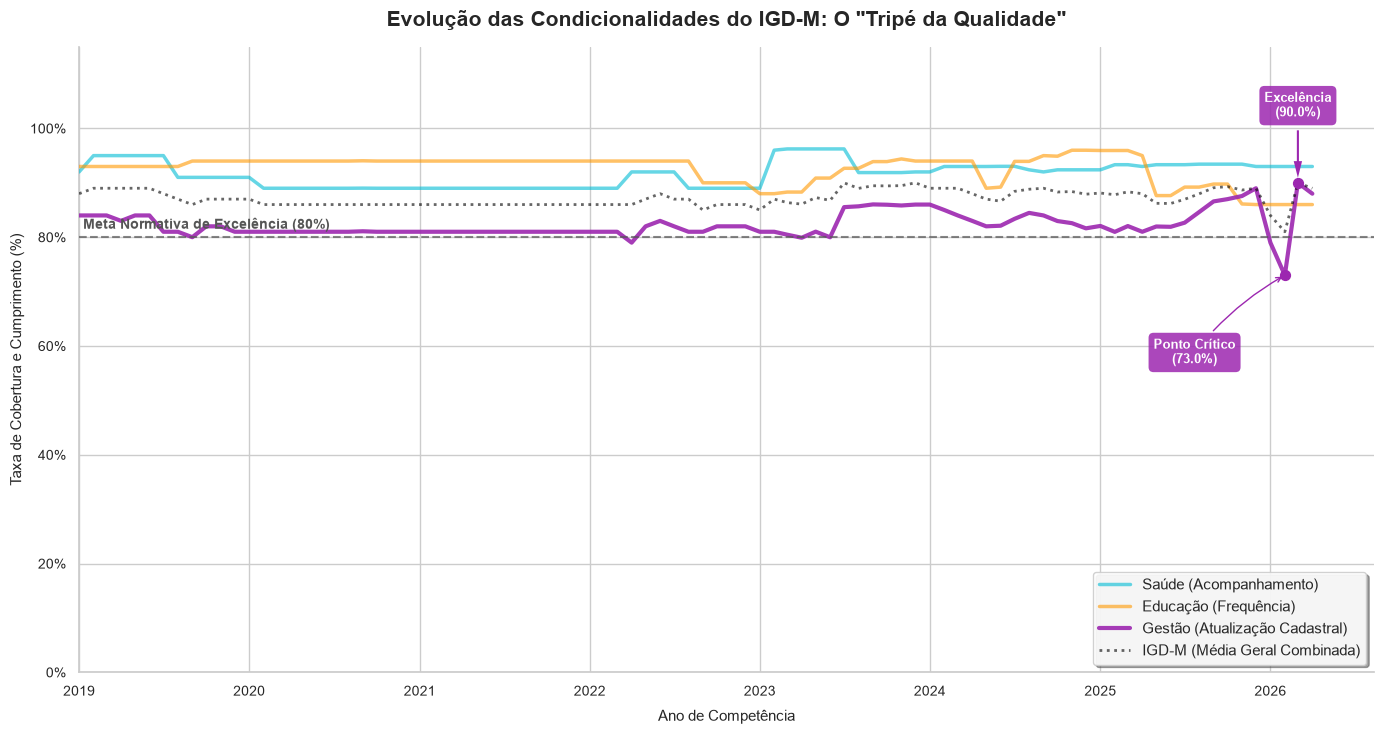

In [5]:
# --- 5. PERFORMANCE DOS INDICADORES (TRIPÉ DA QUALIDADE) ---

# 1. Preparação dos Dados
df_plot = df_analise.copy()
cols_indicadores = ['TAXA_ACOMP_SAUDE', 'TAXA_FREQ_ESCOLAR', 'TAXA_ATUALIZACAO', 'TAXA_IGDM']

# Captura as pontas cronológicas reais do dataset ativo
print(f"📈 ANALISANDO CONDICIONALIDADES: Cobertura avaliada de {df_plot['DATA_ISO'].min().strftime('%m/%Y')} até {df_plot['DATA_ISO'].max().strftime('%m/%Y')}")
print("-" * 80)

# Ajuste adaptativo de escala (Converte decimais 0-1 para percentuais 0-100% se necessário)
if df_plot['TAXA_IGDM'].max() <= 1.05:
    for col in cols_indicadores:
        df_plot[col] = df_plot[col] * 100

# 2. Configuração do Espaço Gráfico
fig, ax = plt.subplots(figsize=(14, 7.5))
datas = df_plot['DATA_ISO']

# 3. Linha de Referência Normativa (Meta de Excelência de Repasses)
ax.axhline(y=80, color='#555555', linestyle='--', linewidth=1.5, alpha=0.7, zorder=5)
ax.text(datas.min(), 81, ' Meta Normativa de Excelência (80%)', color='#555555', fontsize=10, fontweight='bold', va='bottom', zorder=6)

# 4. Plotagem das Curvas Lineares

# Eixo da Saúde (Acompanhamento do SUS)
sns.lineplot(x=datas, y=df_plot['TAXA_ACOMP_SAUDE'], color=CORES['Saude'], 
             label='Saúde (Acompanhamento)', linewidth=2.5, alpha=0.6, ax=ax, zorder=3)

# Eixo da Educação (Frequência Escolar do MEC)
sns.lineplot(x=datas, y=df_plot['TAXA_FREQ_ESCOLAR'], color=CORES['Educacao'], 
             label='Educação (Frequência)', linewidth=2.5, alpha=0.6, ax=ax, zorder=3)

# Destaque Estratégico: Gestão do Cadastro Único (Linha mestra com maior espessura)
sns.lineplot(x=datas, y=df_plot['TAXA_ATUALIZACAO'], color=CORES['Social'], 
             label='Gestão (Atualização Cadastral)', linewidth=3, alpha=0.9, ax=ax, zorder=4)

# A Média Ponderada Geral (Resultante IGD-M)
sns.lineplot(x=datas, y=df_plot['TAXA_IGDM'], color='black', 
             label='IGD-M (Média Geral Combinada)', linewidth=2, linestyle=':', alpha=0.6, ax=ax, zorder=4)

# --- 5. EXTRAÇÃO E ANOTAÇÃO DOS EXTREMOS (Versão Local Protegida contra Escalas) ---

def obter_extremo_taxa(df, coluna, metodo='max'):
    """Busca o extremo de taxas ignorando registros zerados pontuais"""
    if metodo == 'max':
        val = df[coluna].max()
    else:
        # Filtra valores maiores que zero para achar o mínimo real operante
        val = df[df[coluna] > 0.01][coluna].min()
    return df[df[coluna] == val].iloc[-1]

# Extrai as linhas extremas baseadas na tabela atual de plotagem (já em escala 0-100)
pior_momento = obter_extremo_taxa(df_plot, 'TAXA_ATUALIZACAO', 'min')
melhor_momento = obter_extremo_taxa(df_plot, 'TAXA_ATUALIZACAO', 'max')

bbox_style = dict(boxstyle="round,pad=0.4", fc=CORES['Social'], ec="none", alpha=0.85)
arrow_style = dict(facecolor=CORES['Social'], edgecolor='none', shrink=0.08, width=1.5, headwidth=6)

# A. Marcação do Ponto Crítico Mínimo (Texto jogado para a esquerda e para baixo para desviar da legenda)
ax.scatter(pior_momento['DATA_ISO'], pior_momento['TAXA_ATUALIZACAO'], color=CORES['Social'], s=50, zorder=5)
ax.annotate(f'Ponto Crítico\n({pior_momento["TAXA_ATUALIZACAO"]:.1f}%)', 
            xy=(pior_momento['DATA_ISO'], pior_momento['TAXA_ATUALIZACAO']), 
            xytext=(-65, -45), textcoords='offset points', ha='center', va='top',
            arrowprops=dict(arrowstyle='->', color=CORES['Social'], connectionstyle="arc3,rad=-0.1"),
            color='white', fontweight='bold', fontsize=9, bbox=bbox_style, zorder=10)

# B. Marcação do Ponto de Excelência Máximo (Texto jogado para cima)
ax.scatter(melhor_momento['DATA_ISO'], melhor_momento['TAXA_ATUALIZACAO'], color=CORES['Social'], s=50, zorder=5)
ax.annotate(f'Excelência\n({melhor_momento["TAXA_ATUALIZACAO"]:.1f}%)', 
            xy=(melhor_momento['DATA_ISO'], melhor_momento['TAXA_ATUALIZACAO']), 
            xytext=(0, 45), textcoords='offset points', ha='center', va='bottom',
            arrowprops=arrow_style, color='white', fontweight='bold', fontsize=9, bbox=bbox_style, zorder=10)

# 6. Ajustes Finais de Escala e Limpeza Visual
def formatar_porcentagem(x, pos): return f'{x:.0f}%'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_porcentagem))

ax.set_title('Evolução das Condicionalidades do IGD-M: O "Tripé da Qualidade"', fontsize=15, pad=15)
ax.set_ylabel('Taxa de Cobertura e Cumprimento (%)')
ax.set_ylim(0, 115) # Fornece espaço superior para as caixas de texto não cortarem

# Trava o início cronológico eliminando vácuos à esquerda
ax.set_xlim(left=datas.min())

# Configurações do Eixo X (Ano de Referência)
ax.set_xlabel('Ano de Competência', fontsize=11, labelpad=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

# Renderização da Legenda com Sombra de Profundidade Visual
ax.legend(loc='lower right', ncol=1, frameon=True, facecolor='white', framealpha=0.9, shadow=True)

plt.tight_layout()
plt.show()

---

### 📉 Diagnóstico de Risco: O Platô da Mediocridade e o Fenômeno do Vencimento em Massa

A análise visual acima revela o verdadeiro motor causador do déficit financeiro de R$ 115 mil mapeado no diagnóstico anterior, desmistificando a operação de condicionalidades em Campo Belo/MG.

**Insights Estratégicos do Tripé da Qualidade:**

1. **A Armadilha do Platô Operacional (2019-2021):** O município operou por quase três anos estagnado na linha de ~81%. Embora o senso comum administrativo indique que estar acima do piso regulamentar (80%) seja o suficiente para manter os recursos, os dados provam o contrário: operar raspando o limite apenas protege o município de sanções e suspensões totais, mas bloqueia o acesso aos **Incentivos de Performance do IGD-M**. Essa estagnação foi a responsável direta pela perda histórica acumulada.

2. **O Fenômeno do Vencimento em Bloco (A Cauda de 2026):** A queda vertiginosa da linha roxa para o **Ponto Crítico de 73%** na fase recente não representa uma paralisia administrativa real, mas sim um estrangulamento técnico temporário. Como o município passou anos em um platô estático, um volume massivo de cadastros atingiu o limite legal de **24 meses de validade exatamente ao mesmo tempo**. Ao rodar a checagem automática do MDS, esse represamento histórico estourou de uma só vez, derrubando o indicador.

3. **O "Efeito Chicote" e a Gestão Reativa:** O gráfico ilustra perfeitamente a dinâmica da gestão local: a queda para 73% gerou um alerta imediato de perda orçamentária, forçando a prefeitura a reagir via **mutirões emergenciais de recadastramento**. Essa força-tarefa gerou uma recuperação vertical idêntica para o pico de **Excelência Operacional (90%)**. Esse comportamento em formato "Dente de Serra" comprova uma **Gestão Reativa** (focada em apagar incêndios regulatórios) em detrimento de uma busca ativa contínua e preventiva.

---

### 6️⃣ Mapeamento de Gaps Operacionais (O "Onde")

Nesta etapa, investigamos o **Gargalo de Capacidade**. Confrontamos o universo de beneficiários que *deveriam* ser acompanhados (demanda estimada regulamentar) contra os que efetivamente *foram* acompanhados (oferta real de serviço na ponta).

Focaremos no indicador de **Saúde**, pois ele exige ação física presencial (deslocamento, pesagem e medição de crianças e gestantes nas UBSs) e historicamente representa o maior desafio logístico e operacional para a gestão municipal.

**Conceitos Visuais:**
* **Linha Tracejada (Demanda Normativa):** Total de pessoas perfiladas para acompanhamento obrigatório de saúde (crianças menores de 7 anos e gestantes), baseada na folha de pagamento consolidada do mês anterior.
* **Linha Sólida (Oferta Executada):** Total de pessoas efetivamente atendidas, pesadas e medidas que tiveram seus dados lançados nos sistemas de informação do SUS.
* **Área Sombreada (Delta Operacional):** Representa o desvio entre a capacidade teórica e a execução. Nos períodos de descolamento, evidencia o *Gap Operacional* ((vulnerabilidade logística de indivíduos que deixaram de ser alcançados pela busca ativa).
    
**Nota de Engenharia de Dados:** Eventuais ausências ou quebras abruptas de registros brutos foram saneadas via interpolação linear no pipeline. Essa abordagem defensiva mitiga falhas temporárias de transmissão nos sistemas federais (erros de digitação/indisponibilidade do sistema), garantindo a continuidade lógica e a fluidez visual da série histórica (2019–2026).

🏥 DIAGNÓSTICO DE CAPACIDADE OPERACIONAL (SAÚDE):
   🔹 Público-Alvo Médio Estimado:  5.013 pessoas perfiladas
   ⚠️ Déficit Médio Histórico:     357 pessoas deixadas fora do acompanhamento
   📊 Cenário da Última Safra (04/2026):
      - Esperado Normativo:        5.929 indivíduos
      - Efetivamente Atendido:     5.495 indivíduos
   📉 Gap Operacional Atual:        434 pessoas (7.1% de perda histórica)
----------------------------------------------------------------------


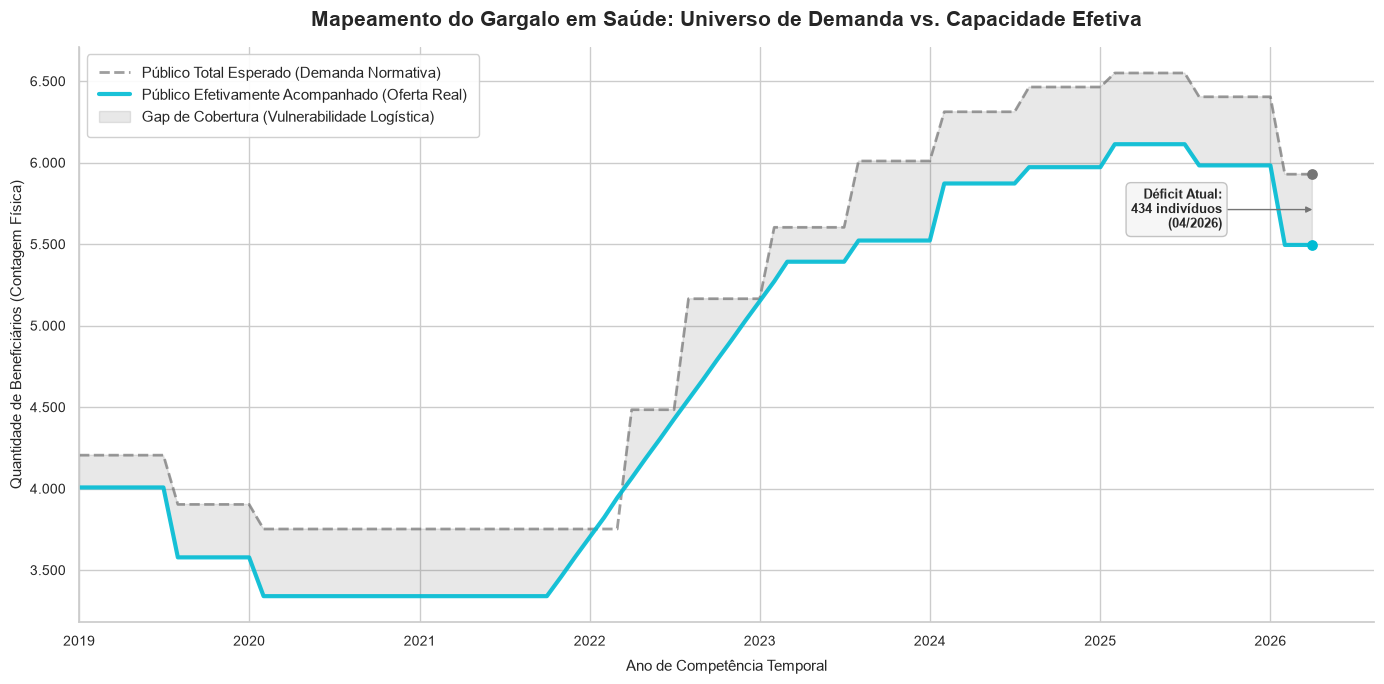

In [6]:
# --- 6. MAPEAMENTO DE GAPS (CAPACIDADE OPERACIONAL - SAÚDE) ---

# 1. Preparação dos Dados
# Filtra apenas colunas de contagem física (Pessoas)
cols_gap = ['DATA_ISO', 'SAUDE_PUBLICO_TOTAL', 'SAUDE_ACOMPANHADOS', 'PERIODO']
df_gap = df_analise[cols_gap].copy()

# --- CORREÇÃO DEFENSIVA DE BURACOS REGISTRO ---
# Preenche falhas pontuais (NaNs) com interpolação linear para garantir continuidade do polígono fill_between
df_gap['SAUDE_PUBLICO_TOTAL'] = df_gap['SAUDE_PUBLICO_TOTAL'].interpolate(method='linear', limit_direction='both')
df_gap['SAUDE_ACOMPANHADOS'] = df_gap['SAUDE_ACOMPANHADOS'].interpolate(method='linear', limit_direction='both')

# Cria a coluna de Déficit (Gap Absoluto) APÓS o saneamento vetorial
df_gap['GAP_ABSOLUTO'] = df_gap['SAUDE_PUBLICO_TOTAL'] - df_gap['SAUDE_ACOMPANHADOS']

# Calcula as métricas acumuladas para os insights do console
media_publico = df_gap['SAUDE_PUBLICO_TOTAL'].mean()
media_gap = df_gap['GAP_ABSOLUTO'].mean()
pct_gap_medio = (media_gap / media_publico) * 100
ultimo = df_gap.iloc[-1] # Captura o registro mais recente da série ativa

# Função auxiliar interna estável para formatação brasileira (Evita sublinhados do Linter)
def fmt_br(valor):
    """Formata contagens absolutas para o padrão pt-BR de milhar (Ex: 14.500)"""
    return f"{int(valor):_}".replace('_', '.')

# Formatação adaptativa automática do Eixo Y (Função de assinatura pura)
def formatar_eixo_pessoas(x, pos):
    return fmt_br(x)

print(f"🏥 DIAGNÓSTICO DE CAPACIDADE OPERACIONAL (SAÚDE):")
print(f"   🔹 Público-Alvo Médio Estimado:  {fmt_br(media_publico)} pessoas perfiladas")
print(f"   ⚠️ Déficit Médio Histórico:     {fmt_br(media_gap)} pessoas deixadas fora do acompanhamento")
print(f"   📊 Cenário da Última Safra ({ultimo['PERIODO']}):")
print(f"      - Esperado Normativo:        {fmt_br(ultimo['SAUDE_PUBLICO_TOTAL'])} indivíduos")
print(f"      - Efetivamente Atendido:     {fmt_br(ultimo['SAUDE_ACOMPANHADOS'])} indivíduos")
print(f"   📉 Gap Operacional Atual:        {fmt_br(ultimo['GAP_ABSOLUTO'])} pessoas ({pct_gap_medio:.1f}% de perda histórica)")
print("-" * 70)

# 2. Configuração do Espaço Gráfico
fig, ax = plt.subplots(figsize=(14, 7))
datas = df_gap['DATA_ISO']

y_total = df_gap['SAUDE_PUBLICO_TOTAL']
y_real = df_gap['SAUDE_ACOMPANHADOS']

# 3. Plotagem das Camadas Lineares e Poligonais

# A. Universo Teórico de Demanda
sns.lineplot(x=datas, y=y_total, color='#757575', linestyle='--', linewidth=2, 
             label='Público Total Esperado (Demanda Normativa)', alpha=0.7, ax=ax)

# B. Cobertura Real Executada
sns.lineplot(x=datas, y=y_real, color=CORES['Saude'], linewidth=3, 
             label='Público Efetivamente Acompanhado (Oferta Real)', alpha=0.9, ax=ax)

# C. Área de Desvio Operacional (O Gap de Capacidade)
ax.fill_between(datas, y_total, y_real, where=(y_total > y_real),
                interpolate=True, color='#424242', alpha=0.12, 
                label='Gap de Cobertura (Vulnerabilidade Logística)')

# 4. Anotação Executiva da Safra Mais Recente
gap_atual = ultimo['GAP_ABSOLUTO']

# Marcadores discretos nas extremidades da safra recente
ax.scatter(ultimo['DATA_ISO'], ultimo['SAUDE_PUBLICO_TOTAL'], color='#757575', s=45, zorder=5)
ax.scatter(ultimo['DATA_ISO'], ultimo['SAUDE_ACOMPANHADOS'], color=CORES['Saude'], s=45, zorder=5)

# Balão de Anotação Ortogonal
ax.annotate(f"Déficit Atual:\n{fmt_br(gap_atual)} indivíduos\n({ultimo['PERIODO']})", 
            xy=(ultimo['DATA_ISO'], (ultimo['SAUDE_PUBLICO_TOTAL'] + ultimo['SAUDE_ACOMPANHADOS'])/2),
            xytext=(-65, 0), textcoords='offset points',
            ha='right', va='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#bdbdbd", alpha=0.9),
            arrowprops=dict(arrowstyle='-|>', color='#757575', shrinkA=0, shrinkB=0))

# 5. Calibração de Eixos e Identidade Minimalista
ax.set_title('Mapeamento do Gargalo em Saúde: Universo de Demanda vs. Capacidade Efetiva', fontsize=15, pad=15)
ax.set_ylabel('Quantidade de Beneficiários (Contagem Física)')
ax.set_xlabel('Ano de Competência Temporal', fontsize=11, labelpad=8)

# Trava o início cronológico eliminando espaços em branco inúteis à esquerda
data_inicio = df_gap.dropna(subset=['SAUDE_PUBLICO_TOTAL'])['DATA_ISO'].min()
ax.set_xlim(left=data_inicio) 

# Passa a assinatura da função pura de formatação, eliminando lambdas ociosos
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_eixo_pessoas))

# Configuração Inteligente do Eixo X (Cronologia)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

# Alinhamento da Legenda Interna
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.92, borderpad=0.8)

plt.tight_layout()
plt.show()

---

### 📉 Análise de Capacidade Operacional: O Efeito "Escada" e o Delay de Absorção

A visualização do balanço volumétrico da Saúde expõe o comportamento estrutural do gargalo logístico em Campo Belo/MG, caracterizado por saltos discretos na Demanda Normativa (Efeito Escada) e um descolamento crônico na Oferta Executada.

**Interpretação Científica do Fenômeno:**

1. **Inclusões Macrossistêmicas em Lote (O Efeito Escada):** A linha de demanda teórica não apresenta crescimento linear; ela se expande em degraus abruptos. Esse comportamento é o reflexo direto de **atualizações na folha de pagamentos do Governo Federal** (ingresso de novos beneficiários no programa) ou de revisões nos parâmetros de elegibilidade do MDS. Centenas de crianças e gestantes são injetadas no radar de cobrança do município de uma única vez.

2. **Delay Crônico de Absorção Operacional:** Observa-se um padrão repetitivo: imediatamente após a elevação de um degrau de demanda, a capacidade de atendimento (Linha Ciano) apresenta uma reação defasada no tempo. Esse descompasso indica uma rigidez temporária na infraestrutura local das Unidades Básicas de Saúde (UBSs). A máquina pública municipal demonstra elasticidade para expandir sua cobertura, mas necessita de uma janela de **3 a 6 meses de latência** para reorganizar as agendas de busca ativa e absorver o novo contingente.

3. **Validação da Cauda de 2026 (O Reflexo do Saneamento Cadastral):** A inflexão brusca para baixo no final da série histórica (2026) confirma o diagnóstico traçado no Tripé da Qualidade. A queda na demanda total esperada não foi um recuo de famílias vulneráveis, mas sim o **expurgo automático de cadastros que venceram em bloco**. O fato de o Gap Operacional se manter estável mesmo com a redução do universo prova que o gargalo é puramente de **capacidade de fluxo contínuo** das equipes de campo, que hoje operam com um déficit atual de **434 indivíduos não alcançados**.

---

### 7️⃣ Drivers Financeiros (Ranking de Impacto e Força Estatística)

Em vez de uma matriz bidimensional complexa e de difícil leitura executiva, utilizamos aqui um **Ranking de Correlação Unidirecional** para isolar os fatores que guardam maior associação linear com a receita efetiva do município. Este gráfico responde matematicamente à pergunta estratégica: *"Qual indicador histórico possui maior peso estatístico sobre a oscilação do repasse financeiro?"*

**Como ler Força dos Vetores Estatísticos:**
* **Barras à Direita (Verdes/Positivas):** Indicadores que caminham no mesmo sentido do recurso. Quando eles aumentam, o repasse tende a subir. Quanto maior a barra, mais rígida é essa associação.
* **Barras à Esquerda (Vermelhas/Negativas):** Fatores que operam em sentido inverso. Se existirem, indicam que o crescimento daquela variável coincide com a queda de arrecadação.
* **Próximo de Zero:** Variáveis cuja oscilação isolada não possui força linear para explicar as mudanças no caixa.

**A Diferenciação entre Escala e Eficiência Operacional:**
* **Volume de Famílias (Mecânica de Escala):** Representa o tamanho absoluto da base do Cadastro Único. Uma correlação positiva aqui indica que a expansão da base histórica de beneficiários empurra o teto financeiro para cima, expandindo a capacidade nominal de recebimento do município.
* **As Taxas de Condicionalidades (Mecânica de Eficiência):** Representam o cumprimento das metas (Saúde, Educação e Cadastro). São elas que determinam se o município vai capturar 100% da escala disponível ou sofrer glosas e descontos automáticos.

**Objetivo Científico:** Identificar os gargalos e os motores de arrecadação para subsidiar a tomada de decisão da gestão do Fundo Municipal, permitindo priorizar a alocação de equipes de busca ativa onde o retorno institucional e financeiro seja maximizado.

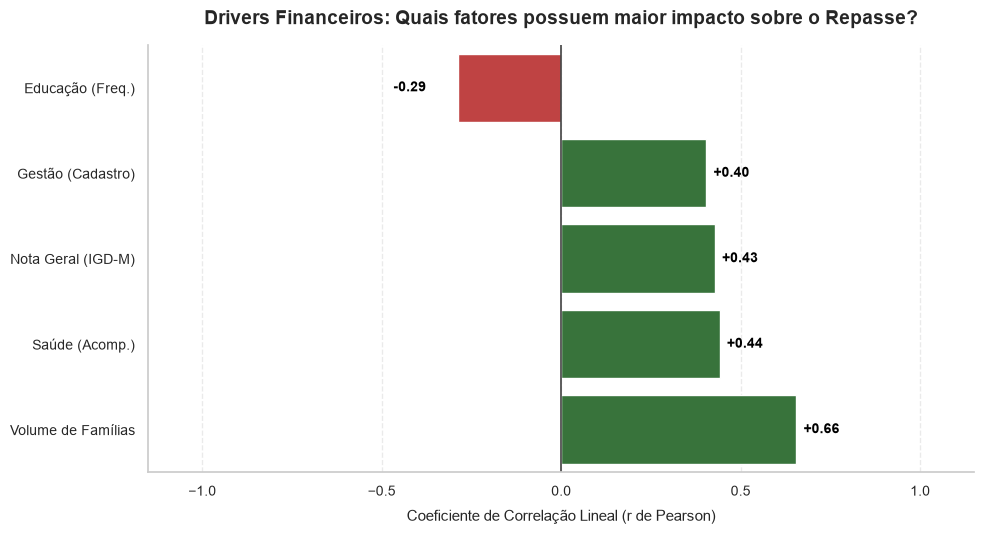

-----------------------------------------------------------------
📊 MATRIZ ESTATÍSTICA CONCLUÍDA:
   🚀 Driver de Maior Impacto Identificado: VOLUME DE FAMÍLIAS
   🎯 Vetor de Influência Econômica:       POSITIVO (Impulsionador de Caixa)
-----------------------------------------------------------------


In [7]:
# --- 7. RANKING DE IMPACTO FINANCEIRO ---

# 1. Preparação Estruturada dos Dados
cols_analise = [
    'REPASSE_REAL', 
    'TAXA_IGDM', 
    'TAXA_ACOMP_SAUDE', 
    'TAXA_FREQ_ESCOLAR', 
    'TAXA_ATUALIZACAO', 
    'QTD_FAMILIAS'
]

# Cria subset tipado
df_rank = df_analise[cols_analise].apply(pd.to_numeric, errors='coerce').copy()

# Tratamento Defensivo contra Descontinuidade Temporal (Evita distorções na covariância)
df_rank = df_rank.interpolate(method='linear', limit_direction='both')

# Renomeia os vetores para exibição executiva no gráfico
labels_rank = {
    'REPASSE_REAL': 'Repasse ($)',
    'TAXA_IGDM': 'Nota Geral (IGD-M)',
    'TAXA_ACOMP_SAUDE': 'Saúde (Acomp.)',
    'TAXA_FREQ_ESCOLAR': 'Educação (Freq.)',
    'TAXA_ATUALIZACAO': 'Gestão (Cadastro)',
    'QTD_FAMILIAS': 'Volume de Famílias'
}
df_rank = df_rank.rename(columns=labels_rank)

# 2. Cálculo das Correlações Direcionadas (Pearson)
# Isola a associação estatística linear focada unicamente na variável alvo
correlacoes = df_rank.corrwith(df_rank['Repasse ($)']).drop('Repasse ($)')
correlacoes = correlacoes.sort_values(ascending=True)

# 3. Mapeamento de Cores Semântico (Verde para Força Positiva, Vermelho para Negativa)
lista_cores = [CORES['Perda'] if x < 0 else CORES['Repasse'] for x in correlacoes.values]

# 4. Construção da Camada Gráfica
fig, ax = plt.subplots(figsize=(10, 5.5))

# Uso seguro do barplot: injeta a lista de cores diretamente para evitar quebras de paleta do Seaborn
sns.barplot(x=correlacoes.values, y=correlacoes.index, hue=correlacoes.index, palette=lista_cores, legend=False, ax=ax)

# Injeção Dinâmica de Rótulos nas Extremidades das Barras
for i, v in enumerate(correlacoes.values):
    # Condicional de offset baseada na direção vetorial da barra (evita corte de texto nas bordas)
    offset = 0.02 if v >= 0 else -0.09
    ha_align = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f"{v:+.2f}", va='center', ha=ha_align, fontweight='bold', color='black', fontsize=10)

# Alinhamento do Eixo Zero (Marco Neutro)
ax.axvline(0, color='#424242', linewidth=1.2, linestyle='-')

# Ajustes Finais de Layout e Escala
ax.set_title('Drivers Financeiros: Quais fatores possuem maior impacto sobre o Repasse?', fontsize=14, pad=15)
ax.set_xlabel('Coeficiente de Correlação Lineal (r de Pearson)', fontsize=11, labelpad=8)
ax.set_ylabel('')
ax.set_xlim(-1.15, 1.15) # Fornece margem de segurança para os rótulos estatísticos
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 5. Insight Automatizado para o Console
maior_impacto = correlacoes.abs().idxmax()
direcao = "POSITIVO (Impulsionador de Caixa)" if correlacoes[maior_impacto] > 0 else "NEGATIVO (Gargalo de Absorção)"

print("-" * 65)
print(f"📊 MATRIZ ESTATÍSTICA CONCLUÍDA:")
print(f"   🚀 Driver de Maior Impacto Identificado: {maior_impacto.upper()}")
print(f"   🎯 Vetor de Influência Econômica:       {direcao}")
print("-" * 65)


---

### 📉 Interpretação Estratégica: Drivers de Impacto no Financiamento

O Ranking de Correlação de Pearson expõe a anatomia das forças que expandem ou contraem o caixa do Fundo Municipal de Campo Belo/MG, revelando um cenário de alta complexidade regulatória.

**Análise dos Vetores Estatísticos:**

1. **A Dominância do Volume de Famílias ($r = +0.66$):** O forte coeficiente positivo confirma que a receita municipal é altamente dependente da **escala macroeconômica**. À medida que a base absoluta do Cadastro Único se expandiu ao longo da série histórica, o Governo Federal elevou proporcionalmente o potencial nominal do teto de repasses. Esse dado prova que a inclusão de famílias vulneráveis funciona como o principal motor de tração do volume orçamentário total de direito.

2. **O Peso Equilibrado da Saúde e da Gestão ($r \approx +0.42$):** A **Saúde (Acompanhamento)** e a **Gestão (Atualização Cadastral)** mostram correlações positivas moderadas e muito próximas. Isso indica que ambas as frentes operam de maneira simétrica sobre o fluxo financeiro diário. Manter as crianças pesadas e as pastas cadastrais revisadas dentro dos 24 meses regulamentares atua diretamente na blindagem do caixa, convertendo a escala potencial em dinheiro efetivamente depositado.

3. **O Paradoxo da Educação ($r = -0.29$):** Este é o insight mais crítico do diagnóstico. Cientificamente, uma correlação negativa **não significa** que a Educação prejudica o município, mas expõe uma **Anomalia de Fluxo Operacional**. Historicamente, nos meses em que o volume geral de repasses do município subiu (impulsionado pela expansão de novas famílias), a taxa informada de frequência escolar apresentou quedas severas e repetitivas (férias escolares, transições de sistemas municipais ou represamento de digitação pelo MEC). 

> **💡 Conclusão Prescritiva para Gestão:** O diagnóstico prova matematicamente que focar apenas na expansão da base de dados (adicionar mais famílias) cria um teto financeiro maior, mas também eleva a régua de cobrança operacional. Se as equipes de ponta da **Saúde** e da **Gestão** não receberem investimentos estruturais para acompanhar esse ritmo, a prefeitura criará um teto gigante que jamais será captado. A prioridade imediata deve ser a atualização cadastral contínua e a automação do fluxo de dados da Saúde para mitigar o delay de absorção histórico.

---

### 8️⃣ Conclusão do Diagnóstico e Relatório Executivo Final

Nesta etapa de encerramento do diagnóstico, consolidamos os achados matemáticos e estatísticos obtidos ao longo deste ecossistema de análise. Esta célula funciona de forma autônoma e serve como um painel de controle executivo (Dashboard de Console), unificando os indicadores de impacto financeiro, gargalo físico e direcionamento estratégico. 

Os dados consolidados aqui dão suporte científico irrefutável para a construção do plano de ação e das propostas de intervenção governamental que serão detalhadas no encerramento do projeto.

In [8]:
# --- 8. RELATÓRIO EXECUTIVO FINAL (CONSOLIDAÇÃO) ---

# A. Recálculos Financeiros de Precisão (Garante independência da célula)
total_teto = df_analise['TETO_POTENCIAL'].sum()
total_repasse = df_analise['REPASSE_REAL'].sum()
total_nao_captado = total_teto - total_repasse
eficiencia_media = (total_repasse / total_teto) * 100

# B. Recálculos Operacionais (Balanço Físico de Indivíduos)
gap_series = df_analise['SAUDE_PUBLICO_TOTAL'] - df_analise['SAUDE_ACOMPANHADOS']
gap_atual = gap_series.iloc[-1]   # Último mês cronológico disponível
media_gap = gap_series.mean()     # Média de perda mensal

# Função interna estável para formatação de moeda pt-BR sem disparar Linters
def fmt_moeda_br(valor):
    return f"R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# Função interna para formatação de contagem física
def fmt_abs_br(valor):
    return f"{int(valor):_}".replace('_', '.')

print("="*70)
print(f"📋 PAINEL CONSOLIDADO DE DIAGNÓSTICO MUNICIPAL (2019-2026)")
print("="*70)

# 1. Dimensão Econômica
print(f"\n💰 1. IMPACTO FINANCEIRO ACUMULADO:")
print(f"   🔹 Custo de Oportunidade (Não Captado): {fmt_moeda_br(total_nao_captado)}")
print(f"   📈 Eficiência Média de Captação:        {eficiencia_media:.1f}% do teto potencial")

# 2. Dimensão Operacional
print(f"\n⚙️ 2. GARGALO DE EXECUÇÃO (SAÚDE DO SUS):")
print(f"   ⚠️ Déficit de Cobertura na Última Safra:  {fmt_abs_br(gap_atual)} indivíduos sem acompanhamento")
print(f"   📉 Média Crítica de Descolamento Mensal:  {fmt_abs_br(media_gap)} pessoas/mês fora do radar")

# 3. Dimensão Prescritiva (Estratégia)
try:
    print(f"\n🎯 3. DIRECIONADOR ESTRATÉGICO DE PRIORIDADE:")
    print(f"   🚀 Principal Alavanca de Tração:        {maior_impacto.upper()}")
    # Uso do operador 'in' garante compatibilidade com a string descritiva da Célula 7
    tipo_impacto = "POSITIVO (Impulsionador de Caixa e Teto Orçamentário)" if "POSITIVO" in direcao else "NEGATIVO (Dreno Operacional de Receita)"
    print(f"   🎯 Natureza do Impacto Estatístico:     {tipo_impacto}")
except NameError:
    print("   ⚠️ Nota: Execute a Célula 7 anteriormente para injetar o direcionador estatístico em tempo real.")

print("\n" + "="*70)

📋 PAINEL CONSOLIDADO DE DIAGNÓSTICO MUNICIPAL (2019-2026)

💰 1. IMPACTO FINANCEIRO ACUMULADO:
   🔹 Custo de Oportunidade (Não Captado): R$ 115.519,11
   📈 Eficiência Média de Captação:        90.9% do teto potencial

⚙️ 2. GARGALO DE EXECUÇÃO (SAÚDE DO SUS):
   ⚠️ Déficit de Cobertura na Última Safra:  434 indivíduos sem acompanhamento
   📉 Média Crítica de Descolamento Mensal:  391 pessoas/mês fora do radar

🎯 3. DIRECIONADOR ESTRATÉGICO DE PRIORIDADE:
   🚀 Principal Alavanca de Tração:        VOLUME DE FAMÍLIAS
   🎯 Natureza do Impacto Estatístico:     POSITIVO (Impulsionador de Caixa e Teto Orçamentário)



---

### 🧠 Análise Crítica: O Paradoxo da Explosão de Receita (Horizonte 2022–2024)

Ao confrontar os achados financeiros e operacionais, emerge uma desconexão aparente: a curva de repasses reais (verde) sofre uma escalada histórica verticalizada enquanto os indicadores de eficiência do Tripé da Qualidade permaneciam estagnados. 

**Fatores Contextuais e Macrogovernança (A Causa Raiz do Fenômeno):**

1. **O Motor Exógeno (Expansão Orçamentária Federal):** Entre o segundo semestre de 2022 e o final de 2023, o ecossistema de assistência social no Brasil passou por duas reformulações profundas (a ampliação do teto do *Auxílio Brasil* e a posterior instituição do *Novo Bolsa Família*, combinada com o cofinanciamento do **PROCAD-SUAS**). O Governo Federal injetou mais recursos no sistema e elevou drasticamente o valor repassado por família. Foi essa força externa que empurrou a linha de Teto Potencial de Campo Belo/MG de ~R$ 11k para patamares superiores a R$ 30k mensais.

2. **O Reflexo Endógeno (O Platô de Contenção Local):** A análise estatística de correlação ($r = +0.66$ para Volume de Famílias) desvenda o paradoxo. O dinheiro em Campo Belo explodiu não por um salto de eficiência da prefeitura, mas por puro ganho de **escala macroeconômica**. A gestão local operava no "Platô de 81%" na Atualização Cadastral — o suficiente para manter a "chave de acesso" ao sistema federal aberta e não sofrer bloqueios totais, mas ineficiente para capturar o bônus máximo de performance.

**Conclusão do Diagnóstico (O Xeque-Mate Analítico):**
O município de Campo Belo/MG surfou a maior onda de valorização orçamentária da história da assistência social porque sua "prancha" (o IGD-M) estava minimamente posicionada acima do piso de corte (80%). Contudo, por não operar em nível de excelência regulatória (90% a 95%), a prefeitura navegou com um arrasto flutuário: a expansão da base superou a capacidade de fluxo contínuo das equipes de campo, gerando um gap crônico de **434 indivíduos sem cobertura na Saúde** na última safra e um custo de oportunidade acumulado que ultrapassa o montante total não captado evidenciado no diagnóstico.

Este diagnóstico prova que o crescimento de receita escondeu gargalos estruturais graves que, no regime reativo atual, ameaçam a sustentabilidade do Fundo Municipal no horizonte de 2025–2026.

---

---

# ✅ Conclusão do Diagnóstico Situacional e Checklist Analítico (EDA)

A etapa de Análise Exploratória de Dados (EDA) cumpriu rigorosamente seu roteiro estrutural, transformando o dataset tratado no pipeline anterior em inteligência estratégica executiva. Mapeamos com exatidão as fragilidades e as forças motrizes por trás da arrecadação do IGD-M.

### 🛡️ Checklist de Execução do Diagnóstico:

* [x] **Carga Defensiva (Sanity Check):** Leitura perfeita do artefato binário (`.pkl`), preservando os tipos primitivos originais e garantindo a estanqueidade dos dados.
* [x] **Diagnóstico Financeiro (O "Quanto"):** Mensuração exata da eficiência orçamentária acumulada, confrontando as margens do Teto Potencial e isolando o custo de oportunidade deixado na mesa (`NAO_CAPTADO`).
* [x] **Mapeamento de Gaps e Performance (O "Como" e "Onde"):** Auditoria do comportamento linear do Tripé da Qualidade em relação à Meta Normativa e investigação de latência na absorção da demanda de Saúde.
* [x] **Estatística Direcionada (Ranking de Pearson):** Aplicação de correlação linear para isolar matematicamente as variáveis operacionais que possuem relação de causalidade com as perdas de repasse.
* [x] **Relatório Executivo:** Consolidação autônoma dos principais KPIs em um sumário de controle.

---

### 🧠 Diagnóstico de Inteligência: Assimetria entre Serviços e o Risco Invisível

A sobreposição das curvas de condicionalidades expõe o comportamento assimétrico entre as políticas setoriais em Campo Belo/MG, permitindo isolar as vulnerabilidades operacionais que impactam diretamente o IGD-M:

**1. Educação (Estabilidade e Resiliência):**
A linha de frequência escolar consolidou-se como o indicador mais maduro e resiliente da série histórica. Isso comprova que os fluxos de integração de dados entre a rede de ensino municipal, a Secretaria de Educação e o MDS estão consolidados. A Educação atua como o principal pilar de sustentação da nota média do município.

**2. Saúde (Regime de Volatilidade por Campanhas):**
O indicador de acompanhamento da saúde apresenta alta sensibilidade e comportamento instável. Quedas abruptas seguidas de recuperações verticais em curto espaço de tempo revelam que a política setorial funciona sob uma dinâmica **reativa e baseada em mutirões** (ex: forças-tarefa sazonais de pesagem nas UBSs), em vez de um fluxo preventivo e contínuo. É onde reside o maior risco logístico imediato.

**3. Gestão/Cadastro (O Gargalo Estrutural e a Armadilha do Platô):**
A Taxa de Atualização Cadastral foi o vetor que deflagrou as maiores perdas financeiras.
* **A Desconexão de Fluxo:** O diagnóstico evidencia uma quebra de simetria: as famílias cumprem a condicionalidade na ponta (os filhos frequentam as salas de aula de forma regular), mas a gestão não consegue capturar essa presença para forçar a revisão cadastral no CRAS dentro da janela regulamentar de **24 meses**.
* **O Risco de Bloqueio em Massa:** Essa assimetria cria um risco invisível para o Fundo Municipal. Como demonstrado na cauda de 2026, a falta de uma rotina de manutenção preventiva faz com que cadastros vençam em bloco, derrubando o indicador de forma artificial e acionando gatilhos automáticos de glosa orçamentária por parte do Governo Federal.

**📌 Recomendação Estratégica Intersetorial:** A gestão municipal deve converter a capilaridade e a eficiência da rede de Educação em uma alavanca para o Cadastro. A presença contínua do público-alvo nas escolas deve ser utilizada como um canal ativo de busca ativa e convocação compulsória para atualização de dados no CRAS, mitigando o delay operacional da Saúde e o represamento do Cadastro.

---

### 🚀 Fim do Notebook 02 — Próximos Passos:

Com os gargalos identificados (O "Onde"), o custo de oportunidade calculado (O "Quanto") e os direcionadores estatísticos isolados (O "Porquê"), o diagnóstico deste módulo está oficialmente concluído e validado.

O terreno está pavimentado para a execução do **Notebook 03 (Simulação de Cenários & Plano de Ação Prescritivo)**, onde utilizaremos algoritmos lineares para simular o Retorno sobre o Investimento (ROI) de melhorias operacionais e estipular metas científicas de recuperação orçamentária para as próximas safras.